In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [7]:
df = pd.read_csv('telco_customer_churn.csv')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
df.TotalCharges = pd.to_numeric(df.TotalCharges, errors='coerce')

In [10]:
df.dropna(how='any', inplace=True)

In [11]:
df.Churn.value_counts()/len(df)*100

,count
Churn,
No,73.421502
Yes,26.578498


In [12]:
x = df.drop(['customerID', 'Churn'], axis=1)
y = df.Churn.values

In [13]:
x.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges'],
      dtype='object')

In [14]:
# Feature encoding
x = pd.get_dummies(x, columns=['gender', 'Partner', 'Dependents',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod'], drop_first=True, dtype=int)

In [15]:
# Splitting data into train and test
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25)

In [16]:
len(x_train)

5274

In [17]:
len(x_test)

1758

In [18]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler
standard_scaling = StandardScaler()
x_train_scaling = standard_scaling.fit_transform(x_train)
x_test_scaling = standard_scaling.transform(x_test)

# KNN Classifiers

In [19]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import SimpleImputer

In [20]:
imputer = SimpleImputer(strategy='mean') # Handled NaN Values

In [21]:
x_train_scaling = imputer.fit_transform(x_train_scaling)

In [22]:
model = KNeighborsClassifier()

In [23]:
# Passing data to classifier
model.fit(x_train_scaling, y_train)

KNeighborsClassifier()

In [24]:
x_test_scaling = imputer.fit_transform(x_test_scaling)

In [25]:
y_prediction = model.predict(x_test_scaling)

In [26]:
y_prediction

array(['No', 'No', 'Yes', ..., 'No', 'No', 'No'], dtype=object)

In [27]:
y_test

array(['No', 'No', 'Yes', ..., 'No', 'No', 'No'], dtype=object)

In [28]:
# Classification metric to check model's behaviour
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, y_prediction)* 100)

77.7019340159272


In [29]:
data = [[0, 2, 87, 178, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1]]

In [30]:
data_scaling = standard_scaling.transform(data)
single = model.predict(data_scaling)
print(single)

['Yes']


In [31]:
data_scaling = standard_scaling.transform(data)
single = model.predict_proba(data_scaling)
print(single)

[[0.2 0.8]]


# Decision Tree Classifier

In [32]:
from sklearn.tree import DecisionTreeClassifier
decision_tree_model = DecisionTreeClassifier(max_depth=2)
# Passing data to classifier
decision_tree_model.fit(x_train_scaling, y_train)

DecisionTreeClassifier(max_depth=2)

In [33]:
decision_tree_y_prediction = decision_tree_model.predict(x_test_scaling)

In [34]:
# Classification metric to check model's behaviour
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, decision_tree_y_prediction)* 100)

80.09101251422071


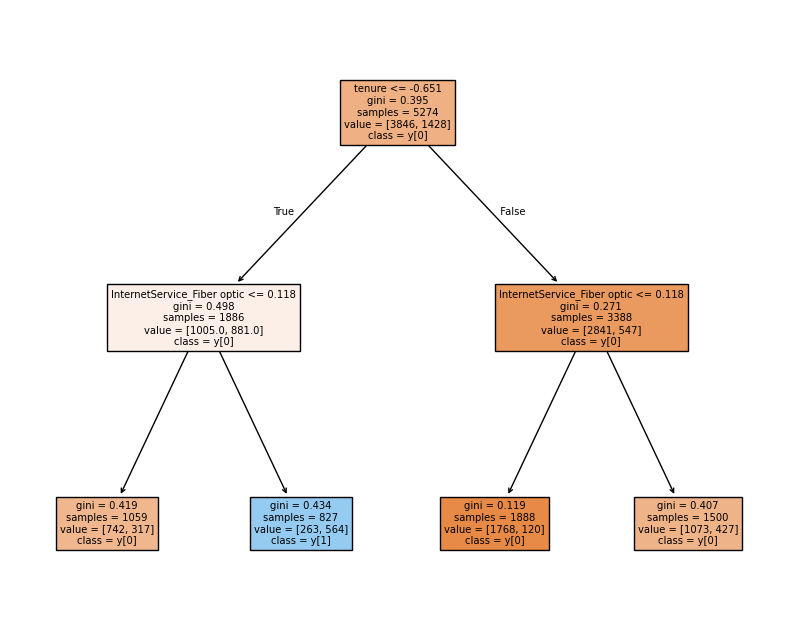

In [35]:
from sklearn.tree import plot_tree
plt.figure(figsize=(10,8))
plot_tree(decision_tree_model, filled=True, feature_names=x_train.columns, class_names=True)
plt.show()

# Random Forest Classifier

In [36]:
from sklearn.ensemble import RandomForestClassifier
random_forest_model = RandomForestClassifier(n_estimators=500)
# Passing data to classifier
random_forest_model.fit(x_train_scaling, y_train)

RandomForestClassifier(n_estimators=500)

In [37]:
random_forest_y_prediction = random_forest_model.predict(x_test_scaling)

In [38]:
# Classification metric to check model's behaviour
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, random_forest_y_prediction)* 100)

79.92036405005688


In [39]:
from sklearn.metrics import classification_report

In [40]:
knn_report = (classification_report(y_test, y_prediction))
decision_tree_report = (classification_report(y_test, decision_tree_y_prediction))
random_forest_report = (classification_report(y_test, random_forest_y_prediction))

In [41]:
print('KNN Report:', knn_report)

KNN Report:               precision    recall  f1-score   support

          No       0.86      0.84      0.85      1317
         Yes       0.55      0.58      0.57       441

    accuracy                           0.78      1758
   macro avg       0.71      0.71      0.71      1758
weighted avg       0.78      0.78      0.78      1758



In [42]:
print('Decision Tree Report:', decision_tree_report)

Decision Tree Report:               precision    recall  f1-score   support

          No       0.82      0.94      0.88      1317
         Yes       0.67      0.40      0.50       441

    accuracy                           0.80      1758
   macro avg       0.75      0.67      0.69      1758
weighted avg       0.79      0.80      0.78      1758



In [43]:
print('Random Forest Report:', random_forest_report)

Random Forest Report:               precision    recall  f1-score   support

          No       0.85      0.89      0.87      1317
         Yes       0.61      0.54      0.57       441

    accuracy                           0.80      1758
   macro avg       0.73      0.71      0.72      1758
weighted avg       0.79      0.80      0.79      1758



# Naive Bayes Classifier

In [44]:
from sklearn.naive_bayes import BernoulliNB
naive_bayes_model = BernoulliNB()
# Passing data to classifier
naive_bayes_model.fit(x_train_scaling, y_train)

BernoulliNB()

In [45]:
naive_bayes_y_prediction = naive_bayes_model.predict(x_test_scaling)

In [46]:
# Classification metric to check model's behaviour
print(accuracy_score(y_test, naive_bayes_y_prediction)* 100)

72.81001137656428


In [47]:
naive_bayes_report = (classification_report(y_test, naive_bayes_y_prediction))
print('Naive Bayes Report:', naive_bayes_report)

Naive Bayes Report:               precision    recall  f1-score   support

          No       0.92      0.70      0.79      1317
         Yes       0.48      0.82      0.60       441

    accuracy                           0.73      1758
   macro avg       0.70      0.76      0.70      1758
weighted avg       0.81      0.73      0.75      1758



# Support Vector Machine Classifier

In [48]:
from sklearn.svm import SVC
svm_model = SVC()
# Passing data to classifier
svm_model.fit(x_train_scaling, y_train)

SVC()

In [49]:
svm_y_prediction = svm_model.predict(x_test_scaling)

In [50]:
# Classification metric to check model's behaviour
print(accuracy_score(y_test, svm_y_prediction)* 100)

81.28555176336747


In [51]:
svm_report = (classification_report(y_test, svm_y_prediction))
print('Naive Bayes Report:', svm_report)

Naive Bayes Report:               precision    recall  f1-score   support

          No       0.86      0.90      0.88      1317
         Yes       0.65      0.54      0.59       441

    accuracy                           0.81      1758
   macro avg       0.75      0.72      0.74      1758
weighted avg       0.80      0.81      0.81      1758



# Logistic Regression Classifier

In [52]:
from sklearn.linear_model import LogisticRegression
logistic_regression_model = LogisticRegression()
# Passing data to classifier
logistic_regression_model.fit(x_train_scaling, y_train)

LogisticRegression()

In [53]:
logistic_regression_y_prediction = logistic_regression_model.predict(x_test_scaling)

In [54]:
# Classification metric to check model's behaviour
print(accuracy_score(y_test, logistic_regression_y_prediction)* 100)

81.17178612059158


In [55]:
logistic_regression_report = (classification_report(y_test, logistic_regression_y_prediction))
print('Naive Bayes Report:', logistic_regression_report)

Naive Bayes Report:               precision    recall  f1-score   support

          No       0.87      0.88      0.88      1317
         Yes       0.63      0.60      0.61       441

    accuracy                           0.81      1758
   macro avg       0.75      0.74      0.74      1758
weighted avg       0.81      0.81      0.81      1758



# Ensemble Learning

In [61]:
from sklearn.ensemble import AdaBoostClassifier
adaboost_model = AdaBoostClassifier(n_estimators=200)
adaboost_model.fit(x_train_scaling, y_train)
adaboost_y_prediction = adaboost_model.predict(x_test_scaling)
print('Accuracy Score of Adaboost: ', accuracy_score(y_test, adaboost_y_prediction) * 100)

Accuracy Score of Adaboost:  80.03412969283276


# Gradient Boosting Algorithm

In [62]:
from sklearn.ensemble import GradientBoostingClassifier
gradient_boosting_model = GradientBoostingClassifier(n_estimators=200)
gradient_boosting_model.fit(x_train_scaling, y_train)
gradient_boosting_y_prediction = gradient_boosting_model.predict(x_test_scaling)
print('Accuracy Score of Gradient Boosting: ', accuracy_score(y_test, gradient_boosting_y_prediction) * 100)

Accuracy Score of Gradient Boosting:  78.72582480091013


# XG Boost Algorithm

In [63]:
# 1. encoding
y[y == 'No'] = 0
y[y == 'Yes'] = 1

y = y.astype('int')

# 2. Splitting data
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25)

# 3. Scaling
from sklearn.preprocessing import StandardScaler
standard_scaling = StandardScaler()
x_train_scaling = standard_scaling.fit_transform(x_train)
x_test_scaling = standard_scaling.transform(x_test)

# 4. Training
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

xg_boost_model = XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1)
xg_boost_model.fit(x_train_scaling, y_train)

# 5. Prediction & Evaluation
xg_boost_y_prediction = xg_boost_model.predict(x_test_scaling)
print('Accuracy Score of XG Boosting: ', accuracy_score(y_test, xg_boost_y_prediction)* 100)

Accuracy Score of XG Boosting:  80.3754266211604
